In [31]:
# AI-Driven Financial News Sentiment Analysis (Advanced Deep Learning + Attention)

## Objective
# Classify financial news headlines into:
# - Positive
# - Neutral
# - Negative

# ## Key Features
# - Advanced NLP preprocessing
# - Class imbalance handling using class weights
# - GloVe embeddings (trainable)
# - Bidirectional LSTM with Attention mechanism
# - Model comparison (baseline vs advanced)
# - Business insights and error analysis

In [32]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, Bidirectional, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
df = pd.read_csv('/content/all-data.csv', encoding='latin-1')
df.columns = ['sentiment', 'text']
df.head()

,sentiment,text
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [34]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,2878
positive,1363
negative,604


In [35]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

In [36]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['sentiment'])

In [37]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=50)

y = df['label']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [39]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(2.6749482401656315), 1: np.float64(0.5612510860121633), 2: np.float64(1.1842346471127405)}


In [40]:
# Download GloVe embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-04-05 11:54:23--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-05 11:54:23--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-05 11:54:24--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [41]:
embedding_index = {}

with open('/content/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

print("Loaded GloVe vectors:", len(embedding_index))

Loaded GloVe vectors: 400000


In [42]:
embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((5000, embedding_dim))

for word, i in word_index.items():
    if i < 5000:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

In [43]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()
        self.dense = Dense(1)

    def call(self, inputs):
        score = self.dense(inputs)              # learn importance
        weights = tf.nn.softmax(score, axis=1)  # normalize
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context

In [44]:
input_layer = Input(shape=(50,))

embedding = Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

lstm = Bidirectional(LSTM(128, return_sequences=True))(embedding)
lstm = Dropout(0.4)(lstm)

lstm = Bidirectional(LSTM(64, return_sequences=True))(lstm)

attention = Attention()(lstm)

dense = Dense(128, activation='relu')(attention)
dense = Dropout(0.3)(dense)

dense = Dense(64, activation='relu')(dense)

output = Dense(3, activation='softmax')(dense)

model = Model(inputs=input_layer, outputs=output)

optimizer = Adam(learning_rate=0.0005)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 100)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 50, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_1 (Attention)         │ (None, 128)            │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923,940 (3.52 MB)

 Trainable params: 923,940 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 45s 312ms/step - accuracy: 0.5346 - loss: 0.9698 - val_accuracy: 0.6254 - val_loss: 0.7798
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 35s 291ms/step - accuracy: 0.6164 - loss: 0.8081 - val_accuracy: 0.6481 - val_loss: 0.8086
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 42s 300ms/step - accuracy: 0.7162 - loss: 0.6538 - val_accuracy: 0.6842 - val_loss: 0.7385
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 41s 300ms/step - accuracy: 0.7887 - loss: 0.5018 - val_accuracy: 0.7461 - val_loss: 0.6458
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 36s 291ms/step - accuracy: 0.8315 - loss: 0.3925 - val_accuracy: 0.7368 - val_loss: 0.7008
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 35s 285ms/step - accuracy: 0.8640 - loss: 0.3337 - val_accuracy: 0.7461 - val_loss: 0.6855


In [46]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Final Accuracy:", accuracy)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7461 - loss: 0.6458
Final Accuracy: 0.7461300492286682


31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step


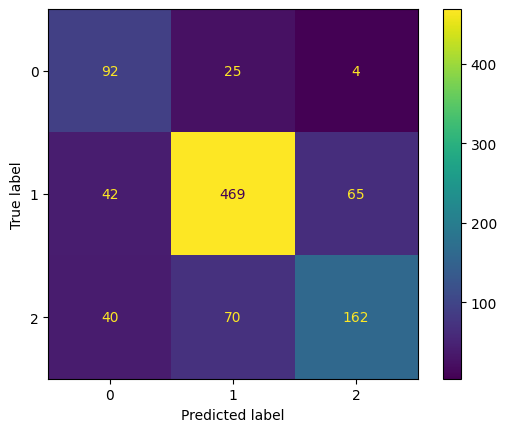

In [47]:
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.76      0.62       121
           1       0.83      0.81      0.82       576
           2       0.70      0.60      0.64       272

    accuracy                           0.75       969
   macro avg       0.69      0.72      0.70       969
weighted avg       0.76      0.75      0.75       969



In [49]:
# Baseline LSTM
baseline = Sequential()
baseline.add(Embedding(5000, 128, input_length=50))
baseline.add(LSTM(64))
baseline.add(Dense(3, activation='softmax'))

baseline.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
baseline.fit(X_train, y_train, epochs=3, batch_size=32, verbose=0)

loss_b, acc_b = baseline.evaluate(X_test, y_test)

comparison = pd.DataFrame({
    "Model": ["Baseline LSTM", "BiLSTM + Attention + GloVe"],
    "Accuracy": [acc_b, accuracy]
})

comparison

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7389 - loss: 0.7198


,Model,Accuracy
0,Baseline LSTM,0.738906
1,BiLSTM + Attention + GloVe,0.746130


In [50]:
df_test = df.iloc[y_test.index].copy()

df_test['predicted'] = encoder.inverse_transform(y_pred)

df_test['signal'] = df_test['predicted'].map({
    'negative': 'Bearish',
    'neutral': 'Neutral',
    'positive': 'Bullish'
})

df_test['signal'].value_counts(normalize=True)

,proportion
signal,
Neutral,0.582043
Bullish,0.238390
Bearish,0.179567


In [51]:
errors = df_test[df_test['label'] != y_pred]

errors[['text', 'sentiment', 'predicted']].head()

,text,sentiment,predicted
1566,Nokia will continue to invest in future develo...,positive,neutral
911,This combined with foreign investments creates...,positive,neutral
3987,"In the Asia-Pacific region , Visa Wave is avai...",positive,neutral
4029,Net loss in the same period in 2009 was euro18...,neutral,negative
1834,After the renovation the biggest moulding line...,positive,neutral


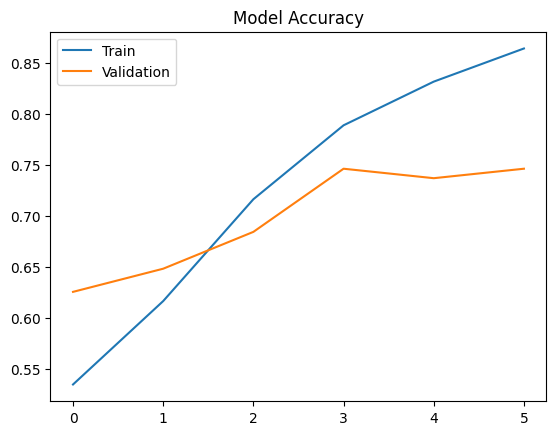

In [52]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.show()

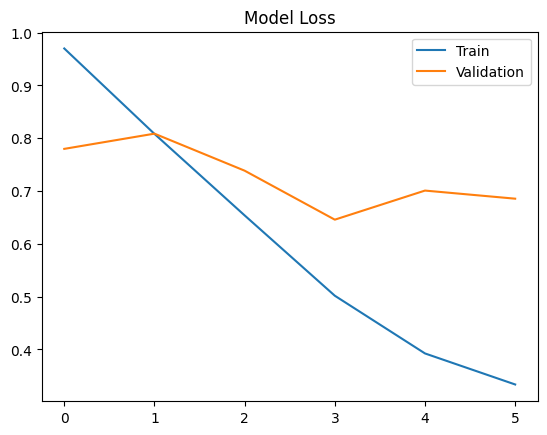

In [53]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Model Loss")
plt.show()

In [54]:
# ## Limitations
# - Dataset size is limited
# - No direct stock market data used
# - Sentiment does not always translate to market movement
# - Model performance depends on quality of financial text

In [55]:
!pip install yfinance

In [56]:
import yfinance as yf

In [57]:
# Example: NIFTY 50 index (India)
stock = yf.download("^NSEI", start="2022-01-01", end="2024-01-01")

stock.head()

/tmp/ipykernel_7085/524737921.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("^NSEI", start="2022-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2022-01-03,17625.699219,17646.650391,17383.300781,17387.150391,200500
2022-01-04,17805.250000,17827.599609,17593.550781,17681.400391,247400
2022-01-05,17925.250000,17944.699219,17748.849609,17820.099609,251500
2022-01-06,17745.900391,17797.949219,17655.550781,17768.500000,236500
2022-01-07,17812.699219,17905.000000,17704.550781,17797.599609,239300


In [58]:
stock['returns'] = stock['Close'].pct_change()

# Direction: 1 = Up, 0 = Down
stock['direction'] = (stock['returns'] > 0).astype(int)

stock.head()

Price,Close,High,Low,Open,Volume,returns,direction
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,
Date,,,,,,,
2022-01-03,17625.699219,17646.650391,17383.300781,17387.150391,200500,NaN,0
2022-01-04,17805.250000,17827.599609,17593.550781,17681.400391,247400,0.010187,1
2022-01-05,17925.250000,17944.699219,17748.849609,17820.099609,251500,0.006740,1
2022-01-06,17745.900391,17797.949219,17655.550781,17768.500000,236500,-0.010005,0
2022-01-07,17812.699219,17905.000000,17704.550781,17797.599609,239300,0.003764,1


In [62]:
df['date'] = pd.date_range(start='2022-01-01', periods=len(df), freq='D')

df.set_index('date', inplace=True)

# Ensure stock only contains the 'direction' column with a single-level index
stock = pd.DataFrame(stock['direction'])

# Merge sentiment + stock
merged = df.join(stock, how='inner')

merged.head()

,sentiment,text,clean_text,label,direction
2022-01-03,positive,With the new production plant the company woul...,new production plant company would increase ca...,2,0
2022-01-04,positive,According to the company 's updated strategy f...,according company updated strategy years baswa...,2,1
2022-01-05,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...,financing aspocomp growth aspocomp aggressivel...,2,1
2022-01-06,positive,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sales doubled eur ...,2,0
2022-01-07,positive,"In the third quarter of 2010 , net sales incre...",third quarter net sales increased eur mn opera...,2,1


In [63]:
# Use predicted sentiment as feature
merged['sentiment_num'] = merged['label']

X_stock = merged[['sentiment_num']]
y_stock = merged['direction']

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_stock, y_stock, test_size=0.2, random_state=42
)

model_stock = LogisticRegression()
model_stock.fit(X_train_s, y_train_s)

LogisticRegression()

In [65]:
from sklearn.metrics import accuracy_score

y_pred_s = model_stock.predict(X_test_s)

print("Stock Direction Accuracy:", accuracy_score(y_test_s, y_pred_s))

Stock Direction Accuracy: 0.5353535353535354


In [66]:
correlation = merged['sentiment_num'].corr(merged['direction'])
print("Sentiment vs Market Correlation:", correlation)

Sentiment vs Market Correlation: -0.08635272534983435


In [67]:
merged['signal'] = merged['sentiment_num'].map({
    0: 'Bearish',
    1: 'Neutral',
    2: 'Bullish'
})

merged['signal'].value_counts(normalize=True)

,proportion
signal,
Bullish,0.724138
Neutral,0.229209
Bearish,0.046653
